In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

import tensorflow as tf
import torch
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


In [2]:
df = pd.read_csv("/content/All_Mrged_Features_Data.csv")
print(df.shape)


(450, 20)


In [3]:
df.head(15)

,Mean,Median,STD,Variance,Min,Max,Range,IQR,Kurtosis,Skewness,MAD,RMS,NumPeaks,Energy,ZCR,FFT_Mean,FFT_Std,PSD_Mean,PSD_Std,Class
0,34.7575,34.7674,20.0573,402.2955,0.005491,69.5560,69.5505,34.7026,1.8008,-0.000766,17.3668,40.1288,880,1.116756e+07,0.000000,0.038645,0.63637,31.4542,277.7013,Stand
1,35.2589,35.2606,20.3387,413.6633,-0.122600,70.6155,70.7381,35.1993,1.8002,0.000018,17.6142,40.7038,1093,1.165060e+07,0.000284,0.038700,0.64102,31.4772,277.8979,Stand
2,31.5035,31.5124,18.1895,330.8594,-0.030130,63.0165,63.0466,31.5212,1.7999,-0.000021,15.7514,36.3769,1549,8.441192e+06,0.000157,0.037814,0.60138,25.1311,221.8724,Stand
3,34.0079,34.0540,19.6587,386.4664,-0.066765,68.0926,68.1594,33.9319,1.8009,-0.003397,17.0191,39.2803,1342,1.048276e+07,0.001030,0.038566,0.62916,30.2436,267.0139,Stand
4,35.0221,34.9898,17.3221,300.0558,4.937620,65.0956,60.1580,29.9485,1.8007,0.000381,15.0018,39.0711,876,9.156273e+06,0.000000,0.039810,0.67633,29.0702,256.6525,Stand
5,39.0630,39.0578,17.8995,320.3907,8.039250,70.1271,62.0879,31.0076,1.7995,0.000285,15.5004,42.9681,1099,1.144495e+07,0.000000,0.040814,0.73648,35.8440,316.4609,Stand
6,33.7698,33.7501,18.3327,336.0881,1.861750,65.5627,63.7009,31.7712,1.8015,-0.000228,15.8754,38.4244,1034,9.366503e+06,0.000000,0.038968,0.64107,28.4058,250.7848,Stand
7,34.4632,34.5284,18.7254,350.6417,2.005140,66.8826,64.8775,32.4786,1.7990,-0.000168,16.2191,39.2211,1136,9.971251e+06,0.000000,0.038993,0.64733,29.5258,260.6759,Stand
8,32.8221,32.8026,17.7619,315.4848,2.074760,63.7683,61.6936,30.7942,1.8001,-0.000499,15.3799,37.3192,1273,8.562468e+06,0.000000,0.038883,0.63265,27.3467,241.4367,Stand
9,31.1100,31.1280,17.9640,322.7052,0.009446,62.2147,62.2052,31.1402,1.8000,-0.000447,15.5565,35.9234,1531,7.945530e+06,0.000000,0.038564,0.60445,25.2393,222.8287,Stand


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Mean      450 non-null    float64
 1   Median    450 non-null    float64
 2   STD       450 non-null    float64
 3   Variance  450 non-null    float64
 4   Min       450 non-null    float64
 5   Max       450 non-null    float64
 6   Range     450 non-null    float64
 7   IQR       450 non-null    float64
 8   Kurtosis  450 non-null    float64
 9   Skewness  450 non-null    float64
 10  MAD       450 non-null    float64
 11  RMS       450 non-null    float64
 12  NumPeaks  450 non-null    int64  
 13  Energy    450 non-null    float64
 14  ZCR       450 non-null    float64
 15  FFT_Mean  450 non-null    float64
 16  FFT_Std   450 non-null    float64
 17  PSD_Mean  450 non-null    float64
 18  PSD_Std   450 non-null    float64
 19  Class     450 non-null    object 
dtypes: float64(18), int64(1), object

In [5]:
df.describe()

,Mean,Median,STD,Variance,Min,Max,Range,IQR,Kurtosis,Skewness,MAD,RMS,NumPeaks,Energy,ZCR,FFT_Mean,FFT_Std,PSD_Mean,PSD_Std
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,4.500000e+02,450.000000,450.000000,450.000000,450.000000,450.000000
mean,22.424934,22.386301,13.064406,206.308296,-2.664267,48.375489,51.039754,21.881330,2.187067,0.046322,11.181290,26.083465,860.868889,5.487625e+06,0.017121,0.053756,0.502019,17.337714,151.325061
std,13.838677,13.880405,5.975696,147.621872,7.572891,20.549516,15.193586,11.163291,0.587666,0.162024,5.318750,14.844859,637.512100,6.446913e+06,0.022171,0.019995,0.182633,17.819930,158.843531
min,2.827510,2.440620,3.314300,10.984500,-20.504400,11.257600,14.987900,4.452250,1.789800,-0.409360,2.739900,4.580130,42.000000,1.248167e+04,0.000000,0.025761,0.198180,0.347980,1.463120
25%,7.902040,7.950883,6.807775,46.345400,-7.996370,27.743350,37.494950,9.718460,1.800000,-0.000298,5.549500,10.462225,149.000000,1.694158e+05,0.000000,0.038528,0.323037,2.008400,13.096250
50%,30.626100,30.615100,17.321900,300.048600,-0.088759,61.263170,60.022335,29.989900,1.800400,0.000075,15.000000,35.328400,1130.500000,7.613334e+06,0.000475,0.039724,0.595640,24.106000,212.821850
75%,32.012310,32.018400,17.950325,322.214025,0.027032,63.443865,62.227150,31.103725,2.506125,0.051212,15.548325,36.868378,1440.000000,8.470103e+06,0.035923,0.067392,0.612700,26.276225,231.978250
max,111.484900,111.522600,29.542300,872.746300,75.008100,147.879900,102.358400,51.180600,7.715100,1.001800,25.582800,113.451200,2383.000000,9.374084e+07,0.082107,0.119560,1.863000,252.314800,2227.734400


Class distribution (%):
 Class
Walk     41.777778
Stand    19.777778
Sit      19.555556
Lay      18.888889
Name: count, dtype: float64
Class imbalance ratio (minority/majority): 0.452


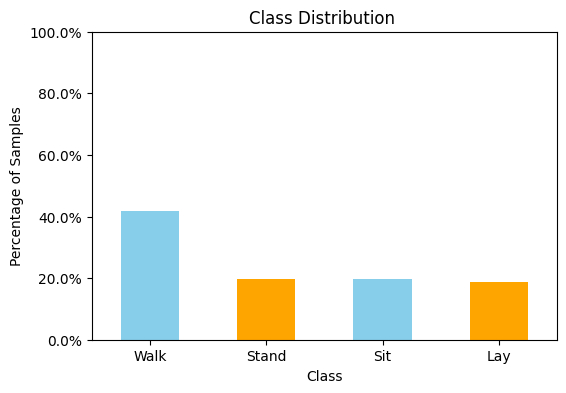

In [6]:


# Check class imbalance
class_counts = df['Class'].value_counts()
total = class_counts.sum()

# Convert counts to percentages
class_percentages = (class_counts / total) * 100

print("Class distribution (%):\n", class_percentages)
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class imbalance ratio (minority/majority): {imbalance_ratio:.3f}")

# Visualization
plt.figure(figsize=(6, 4))
class_percentages.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Class Distribution ')
plt.xlabel('Class')
plt.ylabel('Percentage of Samples')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
plt.show()

In [7]:
mapping = {
    'Stand': 0,
    'Walk': 1,
    'Sit': 2,
    'Lay': 3
}

df['Class_encoded'] = df['Class'].map(mapping)

# Now check if any NaNs remain
if df['Class_encoded'].isna().any():
    print("Unmapped class names:", df.loc[df['Class_encoded'].isna(), 'Class'].unique())

print(df[['Class', 'Class_encoded']].head())

   Class  Class_encoded
0  Stand              0
1  Stand              0
2  Stand              0
3  Stand              0
4  Stand              0


In [8]:
df.drop(columns=['Class'], inplace=True)

In [9]:
label_col = 'Class_encoded'

X = df.drop(columns=[label_col])
y = df[label_col]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data only
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

1D CNN

In [12]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [13]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE (MAIN SOLUTION)
X_train_cnn = np.array(X_train_cnn)

# Remove all extra dimensions (important)
X_train_cnn = np.squeeze(X_train_cnn)

# Ensure it becomes 3D: (samples, timesteps, 1)
if len(X_train_cnn.shape) == 2:
    X_train_cnn = np.expand_dims(X_train_cnn, axis=-1)

print("X_train_cnn shape:", X_train_cnn.shape)

input_shape = (X_train_cnn.shape[1], 1)

# ✅ Correct num_classes safely
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# 1D CNN
x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

# Flatten
x = layers.Flatten()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
cnn_model = tf.keras.Model(inputs, outputs)

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

cnn_model.summary()

# Train
history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_cnn shape: (360, 19, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,452 (283.02 KB)

 Trainable params: 72,452 (283.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5347 - loss: 0.9381 - val_accuracy: 0.5972 - val_loss: 0.7589
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6215 - loss: 0.7102 - val_accuracy: 0.5833 - val_loss: 0.6846
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5868 - loss: 0.6936 - val_accuracy: 0.5278 - val_loss: 0.7565
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6007 - loss: 0.6988 - val_accuracy: 0.5417 - val_loss: 0.7077
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6076 - loss: 0.6824 - val_accuracy: 0.5417 - val_loss: 0.6706
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6076 - loss: 0.6657 - val_accuracy: 0.5278 - val_loss: 0.6900
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6111 - loss: 0.6661 - val_accuracy: 0.5278 - val_loss: 0.7039
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6389 - loss: 0.6587 - val_accuracy: 0.5972 - val_los

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Predict
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core 4 Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", accuracy)
print("🔹 Precision:", precision)
print("🔹 Recall   :", recall)
print("🔹 F1 Score :", f1)

# ✅ Detailed report (per class)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
🔹 Accuracy : 0.6666666666666666
🔹 Precision: 0.6877525252525253
🔹 Recall   : 0.6666666666666666
🔹 F1 Score : 0.6537068160597571

Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.72      0.51        18
           1       1.00      1.00      1.00        38
           2       0.62      0.29      0.40        17
           3       0.36      0.24      0.29        17

    accuracy                           0.67        90
   macro avg       0.60      0.56      0.55        90
weighted avg       0.69      0.67      0.65        90

Confusion Matrix:

[[13  0  2  3]
 [ 0 38  0  0]
 [ 8  0  5  4]
 [12  0  1  4]]


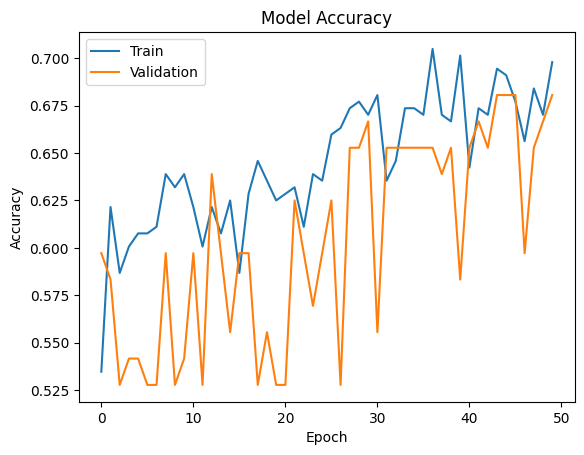

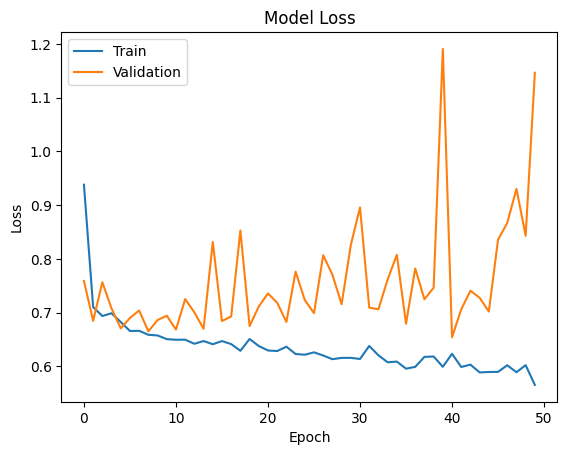

In [15]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

LSTM



In [16]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE PROPERLY
X_train_lstm = np.array(X_train_cnn)

# Remove extra dimensions
X_train_lstm = np.squeeze(X_train_lstm)

# Ensure 3D shape for LSTM: (samples, timesteps, features)
if len(X_train_lstm.shape) == 2:
    X_train_lstm = np.expand_dims(X_train_lstm, axis=-1)

print("X_train_lstm shape:", X_train_lstm.shape)

input_shape = (X_train_lstm.shape[1], 1)

# ✅ Fix labels
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# LSTM Layers
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inputs)
x = layers.BatchNormalization()(x)

x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.BatchNormalization()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
lstm_model = tf.keras.Model(inputs, outputs)

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lstm_model.summary()

# ✅ Train (NO CALLBACKS)
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_lstm shape: (360, 19, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 19, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,612 (361.77 KB)

 Trainable params: 92,228 (360.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.5104 - loss: 1.0617 - val_accuracy: 0.5556 - val_loss: 1.1870
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5972 - loss: 0.8868 - val_accuracy: 0.5417 - val_loss: 1.1094
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5729 - loss: 0.7863 - val_accuracy: 0.6111 - val_loss: 1.0130
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6319 - loss: 0.7452 - val_accuracy: 0.6389 - val_loss: 0.8993
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6354 - loss: 0.7010 - val_accuracy: 0.5833 - val_loss: 0.8097
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6319 - loss: 0.6806 - val_accuracy: 0.6111 - val_loss: 0.9658
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6146 - loss: 0.7025 - val_accuracy: 0.5833 - val_loss: 0.7269
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6528 - loss: 0.6759 - val_accuracy: 0.5833 - 

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# ✅ Prepare test data (IMPORTANT: reshape like train)
X_test_lstm = np.expand_dims(X_test_cnn.squeeze(), axis=-1)

# Predict
y_pred_probs = lstm_model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", round(accuracy, 4))
print("🔹 Precision:", round(precision, 4))
print("🔹 Recall   :", round(recall, 4))
print("🔹 F1 Score :", round(f1, 4))

# ✅ Detailed report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step
🔹 Accuracy : 0.6
🔹 Precision: 0.4815
🔹 Recall   : 0.6
🔹 F1 Score : 0.5111

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       1.00      1.00      1.00        38
           2       0.00      0.00      0.00        17
           3       0.31      0.94      0.47        17

    accuracy                           0.60        90
   macro avg       0.33      0.49      0.37        90
weighted avg       0.48      0.60      0.51        90

Confusion Matrix:
 [[ 0  0  0 18]
 [ 0 38  0  0]
 [ 0  0  0 17]
 [ 1  0  0 16]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

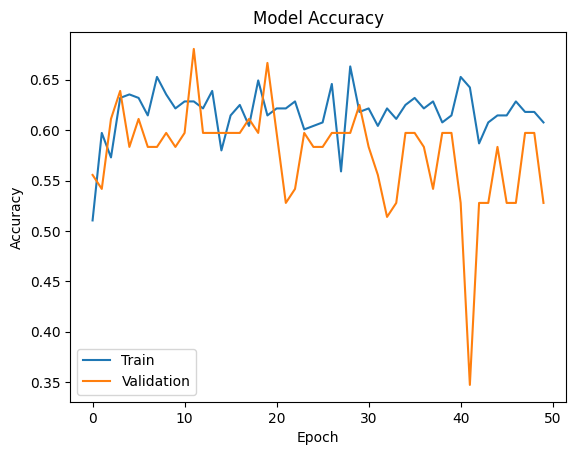

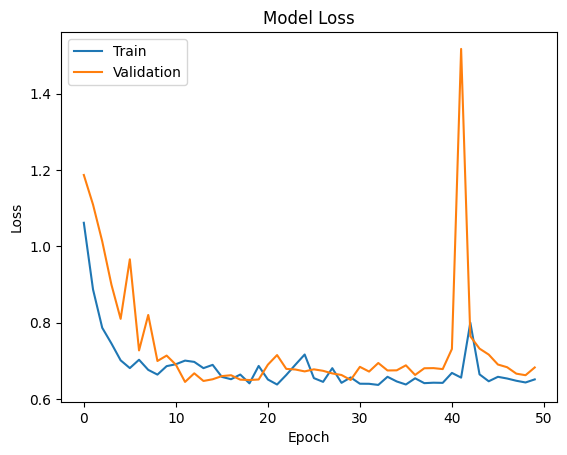

In [18]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

ROC Curve

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


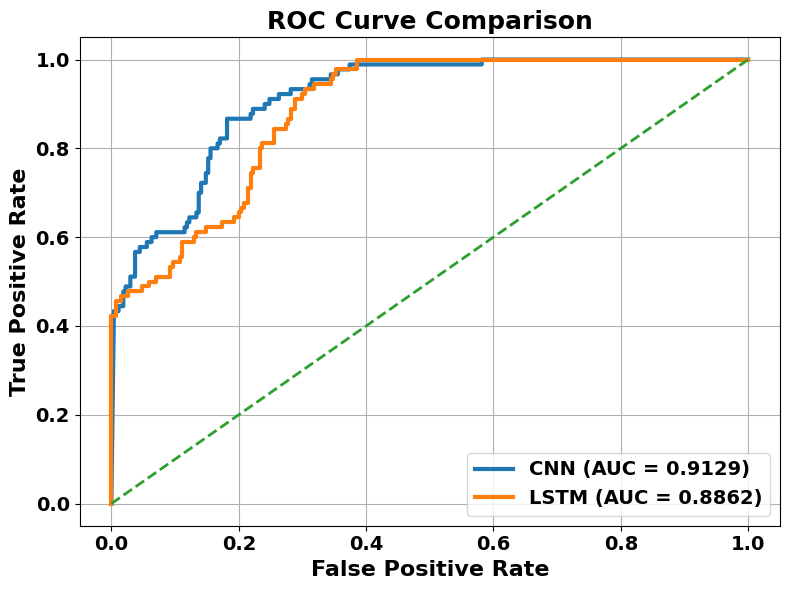

CNN AUC Score : 0.9129218106995886
LSTM AUC Score: 0.8862139917695473


In [19]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# =====================================
# FIX RANDOMNESS (IMPORTANT)
# =====================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# =====================================
# PREPARE TEST DATA
# =====================================

# CNN test shape
X_test_cnn = np.array(X_test_cnn)
X_test_cnn = np.squeeze(X_test_cnn)

if len(X_test_cnn.shape) == 2:
    X_test_cnn = np.expand_dims(X_test_cnn, axis=-1)

# LSTM test shape
X_test_lstm = np.array(X_test_lstm)
X_test_lstm = np.squeeze(X_test_lstm)

if len(X_test_lstm.shape) == 2:
    X_test_lstm = np.expand_dims(X_test_lstm, axis=-1)

# Labels
y_test = np.array(y_test).reshape(-1,)

# =====================================
# BINARIZE LABELS
# =====================================

classes = np.unique(y_test)
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

# =====================================
# MODEL PREDICTIONS
# =====================================

cnn_probs = cnn_model.predict(X_test_cnn)

lstm_probs = lstm_model.predict(X_test_lstm)

# =====================================
# MICRO-AVERAGE ROC
# =====================================

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(
    y_test_bin.ravel(),
    cnn_probs.ravel()
)

roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

# LSTM ROC
fpr_lstm, tpr_lstm, _ = roc_curve(
    y_test_bin.ravel(),
    lstm_probs.ravel()
)

roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# =====================================
# PLOT ROC CURVES
# =====================================

plt.figure(figsize=(8,6))

# CNN
plt.plot(
    fpr_cnn,
    tpr_cnn,
    linewidth=3,
    label=f'CNN (AUC = {roc_auc_cnn:.4f})'
)

# LSTM
plt.plot(
    fpr_lstm,
    tpr_lstm,
    linewidth=3,
    label=f'LSTM (AUC = {roc_auc_lstm:.4f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2
)

# ===== Bigger & Bold Labels =====
plt.xlabel(
    "False Positive Rate",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    "True Positive Rate",
    fontsize=16,
    fontweight='bold'
)

plt.title(
    "ROC Curve Comparison",
    fontsize=18,
    fontweight='bold'
)

# Tick labels size & bold
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# Legend size & bold
legend = plt.legend(
    loc="lower right",
    fontsize=14
)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(True)

plt.tight_layout()
plt.show()
# =====================================
# PRINT AUC SCORES
# =====================================

print("CNN AUC Score :", roc_auc_cnn)
print("LSTM AUC Score:", roc_auc_lstm)